# Password Strength Classifier

Predicts whether a password is **Weak (0)**, **Medium (1)**, or **Strong (2)** based on character-level patterns.

**Approach:** TF-IDF vectorization at the character level + classification (Logistic Regression and Random Forest, compared).

**Dataset:** ~670K passwords labeled by strength, sourced from a public Kaggle password-strength dataset.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

## 2. Load and Inspect Data

In [3]:
df = pd.read_csv("Password Strength.csv", on_bad_lines='skip')
print("Shape:", df.shape)
df.head()

Shape: (669640, 2)


,password,strength
0,kzde5577,1
1,kino3434,1
2,visi7k1yr,1
3,megzy123,1
4,lamborghin1,1


In [4]:
df['strength'].value_counts()

1    496801
0     89702
2     83137
Name: strength, dtype: int64

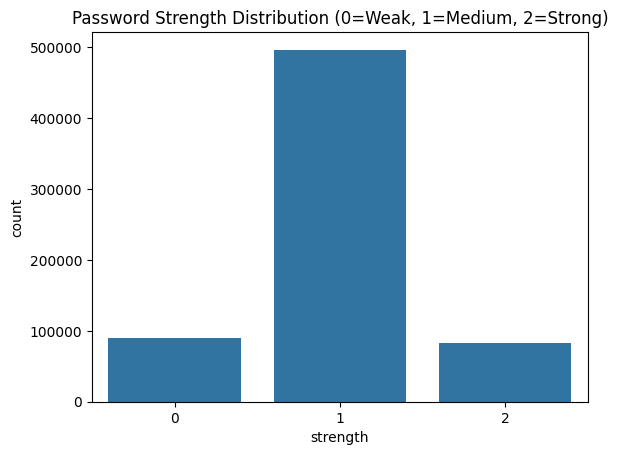

In [5]:
sns.countplot(x='strength', data=df)
plt.title("Password Strength Distribution (0=Weak, 1=Medium, 2=Strong)")
plt.show()

## 3. Data Cleaning

In [6]:
# Check for nulls and duplicates
print("Nulls:\n", df.isnull().sum())
print("\nDuplicate passwords:", df.duplicated(subset='password').sum())

Nulls:
 password    1
strength    0
dtype: int64

Duplicate passwords: 0


In [7]:
df = df.dropna()
df = df.drop_duplicates(subset='password')
print("Shape after cleaning:", df.shape)

Shape after cleaning: (669639, 2)


## 4. Feature Engineering — Character-Level TF-IDF

We treat each password as a sequence of characters (not words) and use TF-IDF to weight character importance.
A custom tokenizer splits each password into individual characters.

In [8]:
def char_tokenizer(password):
    """Split a password string into a list of individual characters."""
    return list(password)

X = df['password'].astype(str)
y = df['strength']

vectorizer = TfidfVectorizer(tokenizer=char_tokenizer, lowercase=False)
X_vec = vectorizer.fit_transform(X)

print("Vectorized feature matrix shape:", X_vec.shape)
print("Vocabulary size (unique characters):", len(vectorizer.vocabulary_))

C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Vectorized feature matrix shape: (669639, 200)
Vocabulary size (unique characters): 200


## 5. Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (535711, 200)
Test shape: (133928, 200)


## 6. Model 1 — Logistic Regression (Baseline)

In [10]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Results")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("F1 Score (weighted):", f1_score(y_test, lr_pred, average='weighted'))
print("\n", classification_report(y_test, lr_pred, target_names=['Weak', 'Medium', 'Strong']))

Logistic Regression Results
Accuracy : 0.8592676662087092
F1 Score (weighted): 0.8424945691646094

               precision    recall  f1-score   support

        Weak       0.58      0.30      0.39     17940
      Medium       0.87      0.95      0.91     99360
      Strong       0.95      0.90      0.92     16628

    accuracy                           0.86    133928
   macro avg       0.80      0.72      0.74    133928
weighted avg       0.84      0.86      0.84    133928



## 7. Model 2 — Random Forest

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=20, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("F1 Score (weighted):", f1_score(y_test, rf_pred, average='weighted'))
print("\n", classification_report(y_test, rf_pred, target_names=['Weak', 'Medium', 'Strong']))

Random Forest Results
Accuracy : 0.8952198196045636
F1 Score (weighted): 0.8772012020367098

               precision    recall  f1-score   support

        Weak       0.96      0.35      0.51     17940
      Medium       0.88      1.00      0.93     99360
      Strong       0.98      0.89      0.93     16628

    accuracy                           0.90    133928
   macro avg       0.94      0.74      0.79    133928
weighted avg       0.90      0.90      0.88    133928



## 8. Model Comparison

In [12]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, lr_pred), accuracy_score(y_test, rf_pred)],
    'F1 (weighted)': [f1_score(y_test, lr_pred, average='weighted'), f1_score(y_test, rf_pred, average='weighted')]
})
results

,Model,Accuracy,F1 (weighted)
0,Logistic Regression,0.859268,0.842495
1,Random Forest,0.895220,0.877201


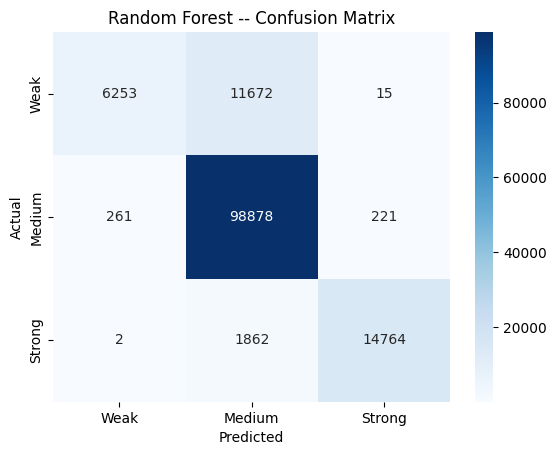

In [13]:
# Confusion matrix for the better-performing model (Random Forest)
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Weak', 'Medium', 'Strong'],
            yticklabels=['Weak', 'Medium', 'Strong'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest -- Confusion Matrix")
plt.show()

## 9. Save Model Artifacts

We save the trained model and vectorizer so they can be loaded directly by the API (`app.py`) without retraining.

In [14]:
joblib.dump(rf_model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")
print("Saved model.pkl and vectorizer.pkl")

Saved model.pkl and vectorizer.pkl


## 10. Quick Manual Test

In [15]:
def predict_password_strength(password):
    vec = vectorizer.transform([password])
    pred = rf_model.predict(vec)[0]
    labels = {0: "Weak", 1: "Medium", 2: "Strong"}
    return labels[pred]

test_passwords = ["abc123", "Password1", "Xk9#mPz2Qw!", "qwerty"]
for pw in test_passwords:
    print(f"{pw:15s} -> {predict_password_strength(pw)}")

abc123          -> Medium
Password1       -> Medium
Xk9#mPz2Qw!     -> Strong
qwerty          -> Medium
